---
title: Multivariate > Pre-factor Analysis
jupyter: python3
---

<div class="alert alert-info">Use pre-factor diagnostics to evaluate whether your data are appropriate for factor analysis before extracting factors.</div>

The goal of Factor Analysis (and Principal Components Analysis) is to reduce the dimensionality of the data with minimal loss of information by identifying and using the structure in the correlation matrix of the variables included in the analysis. The researcher will often try to link the original variables (or _items_) to an underlying factor and provide a descriptive label for each.

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## Example: Toothpaste

We start by loading the `toothpaste` dataset from the package's example data. The dataset contains information from 60 consumers who were asked to respond to six questions to determine their attitudes towards toothpaste. The scores shown for variables v1-v6 indicate the level of agreement with statements on a 7-point scale where 1 = strongly disagree and 7 = strongly agree.

In [3]:
toothpaste = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/toothpaste.parquet"
)
toothpaste.head()

id,v1,v2,v3,v4,v5,v6,age,age.cat,gender
i32,i32,i32,i32,i32,i32,i32,i32,enum,enum
1,7,3,6,4,2,4,50,"""> 40""","""Female"""
2,1,3,2,4,5,4,27,"""< 30""","""Female"""
3,6,2,7,4,1,3,24,"""< 30""","""Female"""
4,4,5,4,6,2,5,21,"""< 30""","""Female"""
5,1,2,2,3,6,2,34,"""30 to 39""","""Female"""


The first step in factor analysis is to determine if the data has the required characteristics. Data with limited or no correlation between the variables are not appropriate for factor analysis. We will use three criteria to test if the data are suitable for factor analysis: Bartlett, KMO, and Collinearity for each variable.

The KMO and Bartlett test evaluate all available data together. A KMO value over 0.5 and a significance level for the Bartlett's test below 0.05 suggest there is substantial correlation in the data. Variable collinearity indicates how strongly a single variable is correlated with other variables. Values above 0.4 are considered appropriate. KMO measures can also be calculated for each variable. Values above 0.5 are acceptable.

## Step 1 — Pre-factor diagnostics

To replicate the diagnostics in Python, pass the data and the variables of interest (`v1` through `v6`) to `pre_factor` and then call `summary()`. The data argument is a dictionary that maps a dataset name to a (polars or pandas) data frame.

In [4]:
pf = rsm.multivariate.pre_factor({"toothpaste": toothpaste}, vars="v1:v6")
pf.summary()

Pre-factor analysis diagnostics
Data        : toothpaste
Variables   : v1, v2, v3, v4, v5, v6
Observations: 60
Correlation : Pearson

Bartlett test
Null hyp. : variables are not correlated
Alt. hyp. : variables are correlated
Chi-square: 238.93 df(15), p.value < .001

KMO test: 0.66

Variable collinearity:
shape: (6, 3)
┌─────┬──────┬──────┐
│     ┆ Rsq  ┆ KMO  │
│ --- ┆ ---  ┆ ---  │
│ str ┆ f64  ┆ f64  │
╞═════╪══════╪══════╡
│ v1  ┆ 0.86 ┆ 0.62 │
│ v2  ┆ 0.48 ┆ 0.7  │
│ v3  ┆ 0.81 ┆ 0.68 │
│ v4  ┆ 0.54 ┆ 0.64 │
│ v5  ┆ 0.76 ┆ 0.77 │
│ v6  ┆ 0.59 ┆ 0.56 │
└─────┴──────┴──────┘

Fit measures:
shape: (6, 4)
┌─────┬─────────────┬────────────┬──────────────┐
│     ┆ Eigenvalues ┆ Variance % ┆ Cumulative % │
│ --- ┆ ---         ┆ ---        ┆ ---          │
│ str ┆ f64         ┆ f64        ┆ f64          │
╞═════╪═════════════╪════════════╪══════════════╡
│ PC1 ┆ 2.73        ┆ 45.52      ┆ 45.52        │
│ PC2 ┆ 2.22        ┆ 36.97      ┆ 82.49        │
│ PC3 ┆ 0.44        ┆ 7.36       ┆ 

As can be seen in the output above, Bartlett's test statistic is large and significant (p.value close to 0) as desired. The Kaiser-Meyer-Olkin (KMO) measure is larger than .5 and thus acceptable. The variable collinearity values are above 0.4 and the KMO values are above 0.5 so all variables can be used in the analysis.

The diagnostics shown in the summary are also available as attributes for programmatic access:

- `pf.btest` — Bartlett's test of sphericity (chi-square, degrees of freedom, p.value)
- `pf.pre_kmo` — the overall KMO measure of sampling adequacy
- `pf.msai` — the measure of sampling adequacy per variable (per-variable KMO)
- `pf.pre_r2` — the per-variable collinearity Rsq
- `pf.pre_eigen` — the eigenvalues of the correlation matrix
- `pf.cmat` — the correlation matrix used as input

In [5]:
print("Bartlett's test:", pf.btest)
print("Overall KMO:", round(pf.pre_kmo, 3))
print("Eigenvalues:", pf.pre_eigen.round(3))

Bartlett's test: {'chisq': 238.93480121131182, 'df': 15.0, 'p.value': 2.3444160474027527e-42}
Overall KMO: 0.66
Eigenvalues: [2.731 2.218 0.442 0.341 0.183 0.085]


## Step 2 — How many factors?

The next step is to determine the number of factors needed to capture the structure underlying the data. Factors that do not capture even as much variance as could be expected by chance are generally omitted from further consideration. These factors have eigenvalues < 1 in the output.

A further criteria that is often used to determine the number of factors is the scree-plot. This is a plot of the eigenvalues against the number of factors, in order of extraction. Often a break or _elbow_ is visible in the plot. Factors up to and including this elbow are selected for further analysis if they all have eigenvalues above 1. A set of factors that explain more than 70% of the variance in the original data is generally considered acceptable. The eigenvalues for all factors are shown in the "Fit measures" table above. Only two factors have eigenvalues above 1.

The scree plot uses a cutoff line at an eigenvalue of 1: factors that sit above this line capture more variance than a single standardized item and are candidates for retention. The `change` plot shows the size of the drop in eigenvalues between successive factors, which helps locate the elbow.

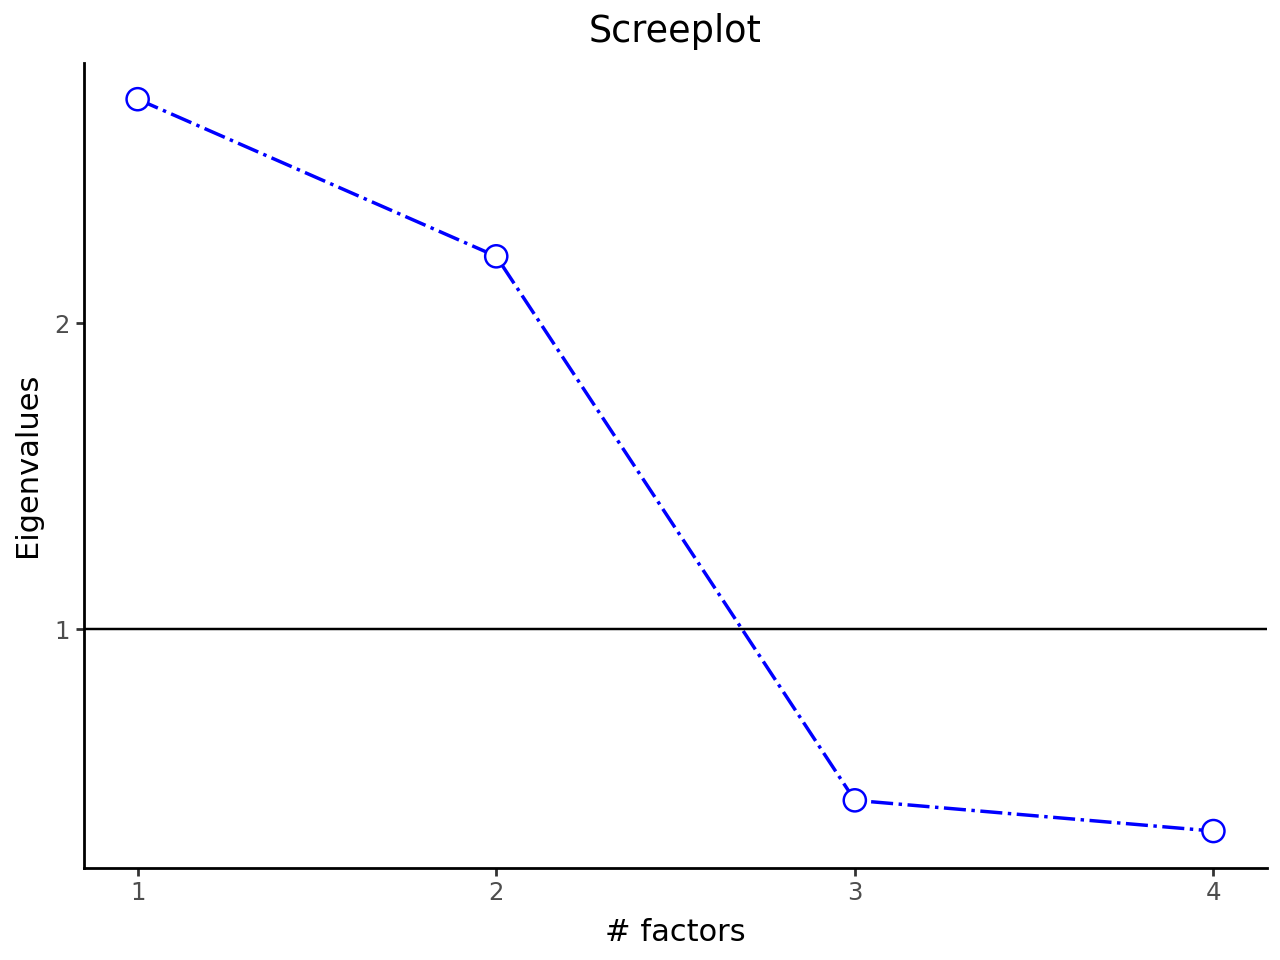

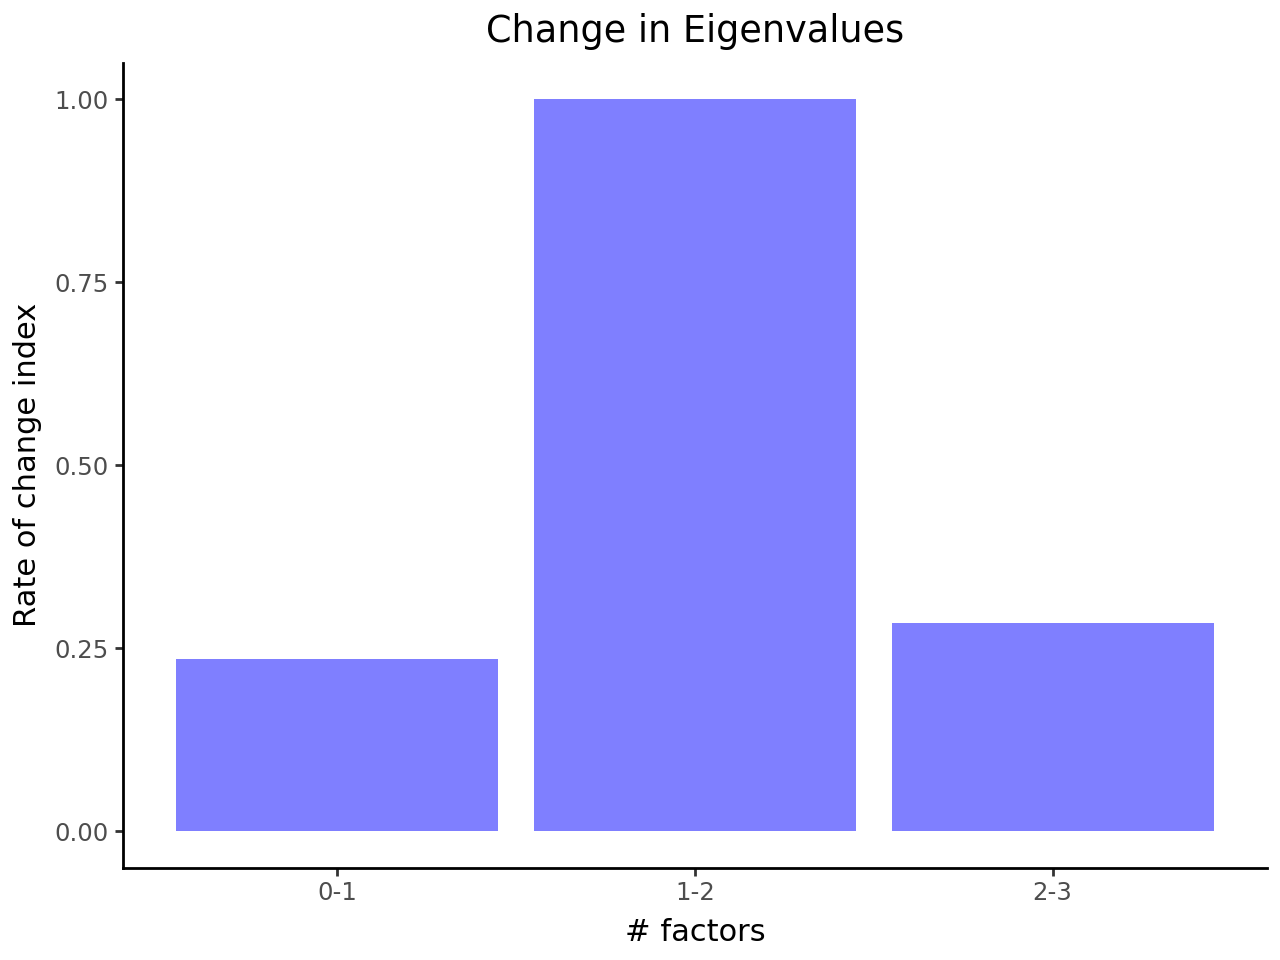

In [6]:
pf.plot(plots=["scree", "change"])

At first glance the scree-plot of the Eigenvalues shown above seems to suggest that 3 factors should be extracted (i.e., look for the _elbow_). The bar plot of the change in eigenvalues confirms this insight, i.e., the change in Eigenvalues between factors 1 and 2 is small but the drop-off from 2 to 3 is much larger. However, because the value for the third factor is less than one we will extract only 2 factors.

The increase in cumulative % explained variance is relatively small going from 2 to 3 factors (i.e., from 82% to 90%). This is confirmed by the fact that the eigenvalue for factor 3 is smaller than 1 (0.44). Again, we choose 2 factors. The first 2 factors capture 82% of the variance in the original data which is excellent.

The two diagnostic plots can also be requested individually:

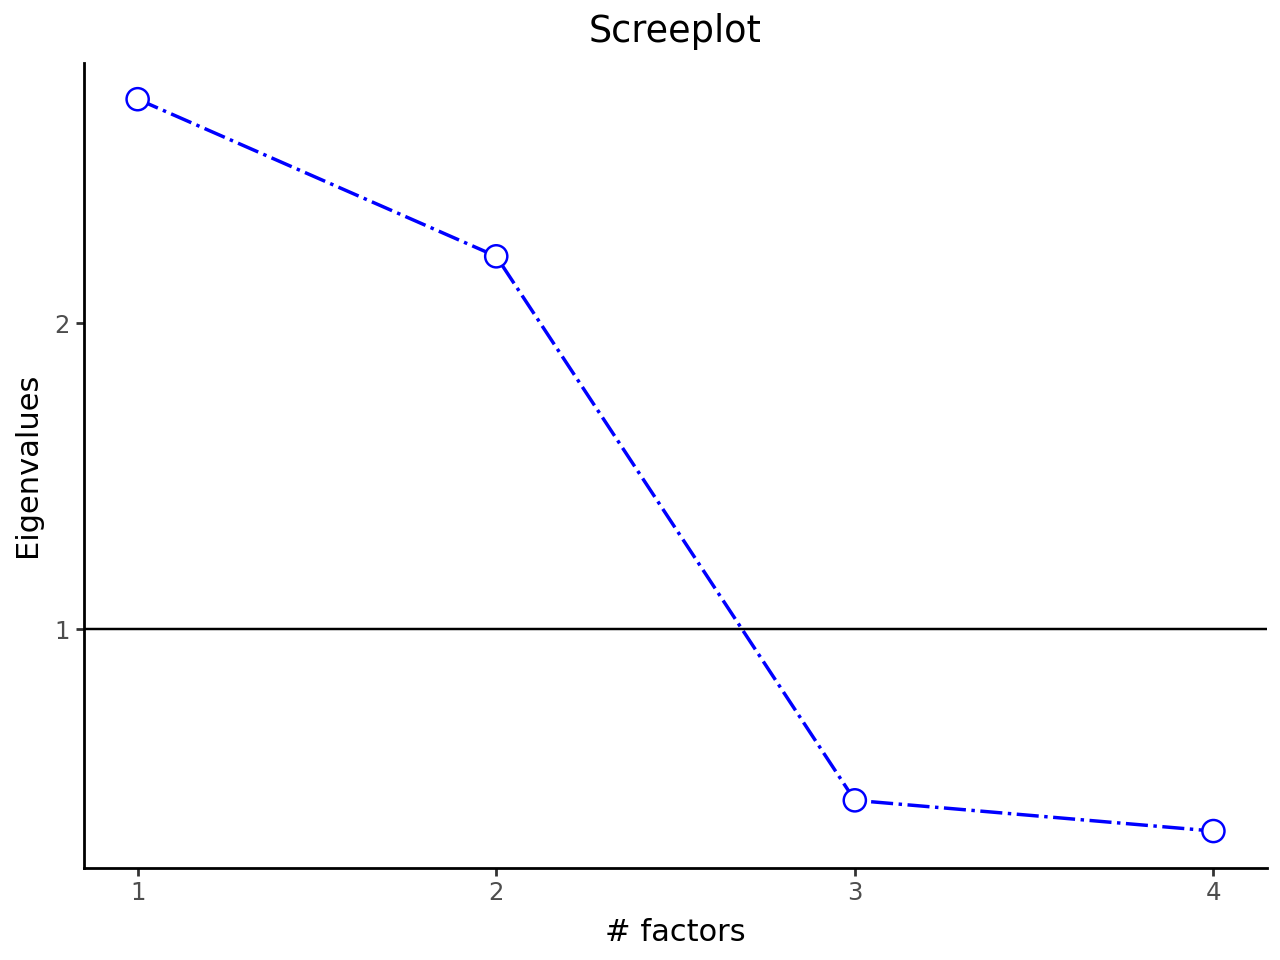

In [7]:
pf.plot(plots="scree")

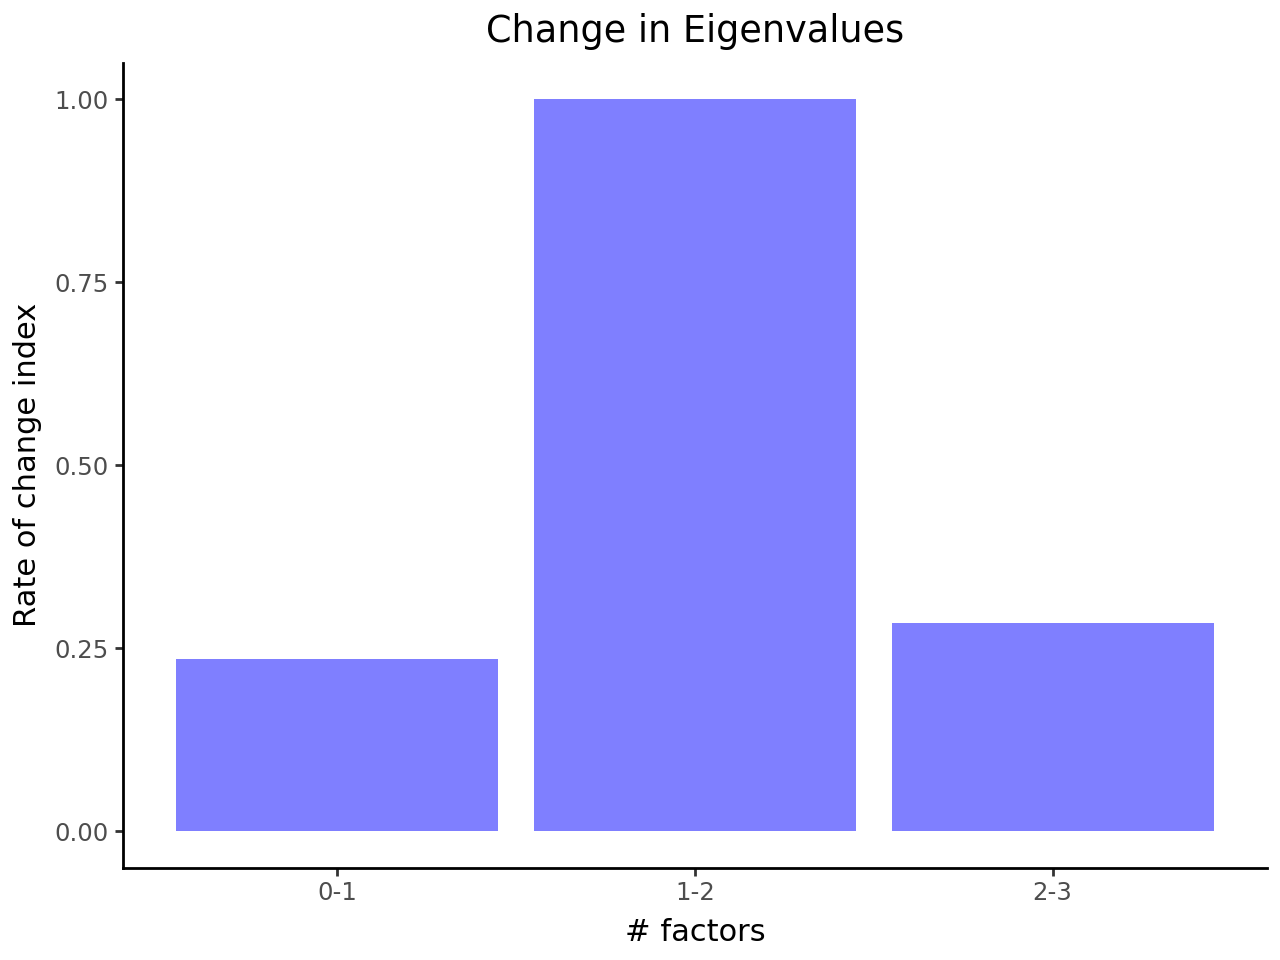

In [8]:
pf.plot(plots="change")

## A second example: Shopping

To practice reading the diagnostics, repeat the analysis on the `shopping` dataset, which also contains six attitudinal items (`v1`–`v6`).

In [9]:
shopping = pl.read_parquet(
    "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/examples/data/multivariate/shopping.parquet"
)
shopping.head()

id,v1,v2,v3,v4,v5,v6
i32,i32,i32,i32,i32,i32,i32
1,6,4,7,3,2,3
2,2,3,1,4,5,4
3,7,2,6,4,1,3
4,4,6,4,5,3,6
5,1,3,2,2,6,4


In [10]:
pf_shop = rsm.multivariate.pre_factor({"shopping": shopping}, vars="v1:v6")
pf_shop.summary()

Pre-factor analysis diagnostics
Data        : shopping
Variables   : v1, v2, v3, v4, v5, v6
Observations: 20
Correlation : Pearson

Bartlett test
Null hyp. : variables are not correlated
Alt. hyp. : variables are correlated
Chi-square: 66.71 df(15), p.value < .001

KMO test: 0.55

Variable collinearity:
shape: (6, 3)
┌─────┬──────┬──────┐
│     ┆ Rsq  ┆ KMO  │
│ --- ┆ ---  ┆ ---  │
│ str ┆ f64  ┆ f64  │
╞═════╪══════╪══════╡
│ v1  ┆ 0.89 ┆ 0.52 │
│ v2  ┆ 0.38 ┆ 0.78 │
│ v3  ┆ 0.79 ┆ 0.59 │
│ v4  ┆ 0.59 ┆ 0.48 │
│ v5  ┆ 0.81 ┆ 0.64 │
│ v6  ┆ 0.58 ┆ 0.43 │
└─────┴──────┴──────┘

Fit measures:
shape: (6, 4)
┌─────┬─────────────┬────────────┬──────────────┐
│     ┆ Eigenvalues ┆ Variance % ┆ Cumulative % │
│ --- ┆ ---         ┆ ---        ┆ ---          │
│ str ┆ f64         ┆ f64        ┆ f64          │
╞═════╪═════════════╪════════════╪══════════════╡
│ PC1 ┆ 2.66        ┆ 44.41      ┆ 44.41        │
│ PC2 ┆ 2.15        ┆ 35.83      ┆ 80.24        │
│ PC3 ┆ 0.47        ┆ 7.88       ┆ 88.

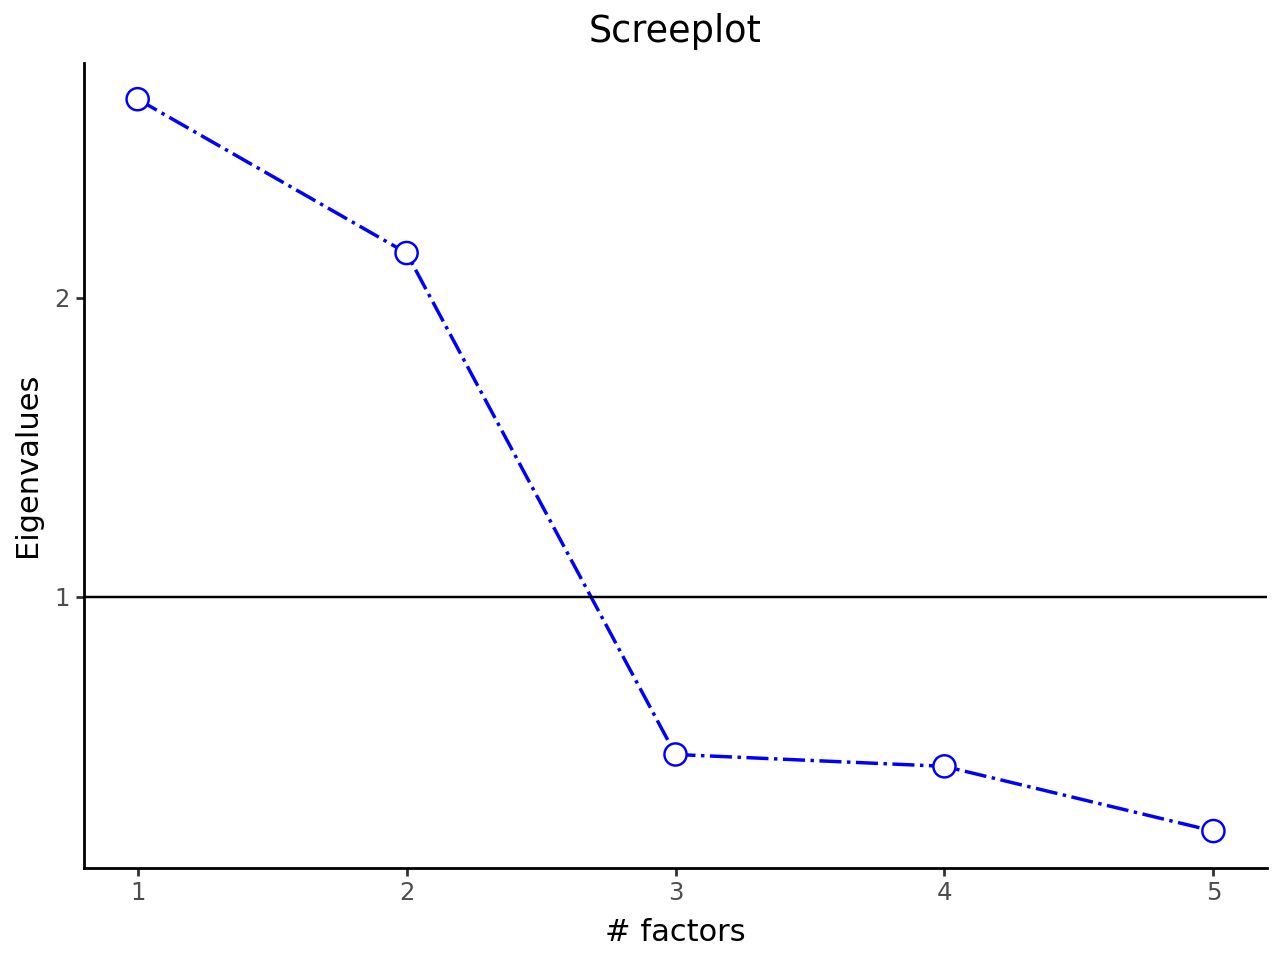

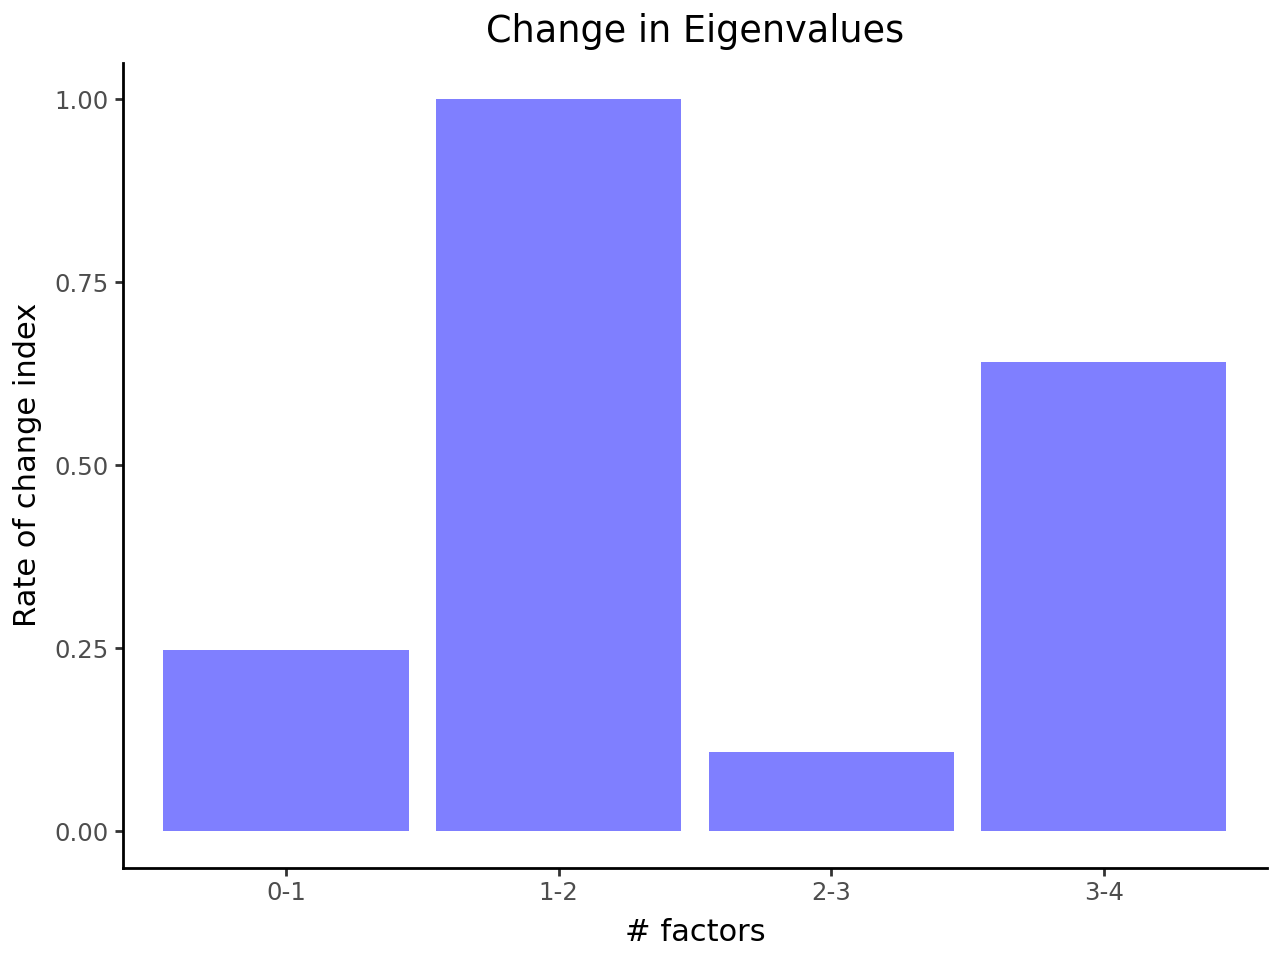

In [11]:
pf_shop.plot(plots=["scree", "change"])

Apply the same checklist to this output: Is Bartlett's test significant? Is the overall KMO above 0.5, and are the per-variable KMO values above 0.5? Are the collinearity Rsq values above 0.4? Finally, how many eigenvalues are above 1, and where does the elbow appear in the scree plot? These answers together suggest whether the data are suitable for factor analysis and how many factors to retain.

## Filtering the data

You can restrict the analysis to a subset of observations with `data_filter`. The filter is a string expression evaluated against the data. For example, to keep only respondents whose `v1` score is greater than 2:

In [12]:
pf_filtered = rsm.multivariate.pre_factor(
    {"toothpaste": toothpaste}, vars="v1:v6", data_filter="v1 > 2"
)
pf_filtered.summary()

Pre-factor analysis diagnostics
Data        : toothpaste
Variables   : v1, v2, v3, v4, v5, v6
Observations: 42
Correlation : Pearson

Bartlett test
Null hyp. : variables are not correlated
Alt. hyp. : variables are correlated
Chi-square: 158.53 df(15), p.value < .001

KMO test: 0.75

Variable collinearity:
shape: (6, 3)
┌─────┬──────┬──────┐
│     ┆ Rsq  ┆ KMO  │
│ --- ┆ ---  ┆ ---  │
│ str ┆ f64  ┆ f64  │
╞═════╪══════╪══════╡
│ v1  ┆ 0.79 ┆ 0.78 │
│ v2  ┆ 0.7  ┆ 0.78 │
│ v3  ┆ 0.75 ┆ 0.76 │
│ v4  ┆ 0.56 ┆ 0.77 │
│ v5  ┆ 0.67 ┆ 0.66 │
│ v6  ┆ 0.55 ┆ 0.7  │
└─────┴──────┴──────┘

Fit measures:
shape: (6, 4)
┌─────┬─────────────┬────────────┬──────────────┐
│     ┆ Eigenvalues ┆ Variance % ┆ Cumulative % │
│ --- ┆ ---         ┆ ---        ┆ ---          │
│ str ┆ f64         ┆ f64        ┆ f64          │
╞═════╪═════════════╪════════════╪══════════════╡
│ PC1 ┆ 3.75        ┆ 62.55      ┆ 62.55        │
│ PC2 ┆ 1.12        ┆ 18.66      ┆ 81.21        │
│ PC3 ┆ 0.45        ┆ 7.55       ┆ 

Filtering changes the sample used to compute the correlation matrix, so the diagnostics (and the number of observations reported) will differ from the full-sample analysis above.

## Including categorical variables

The pre-factor analysis diagnostics are calculated using Principal Components Analysis (PCA). The correlation matrix used as input for PCA can be calculated for variables of type `numeric`, `integer`, `date`, and `factor`. When variables of type factor are included, set `hcor=True`. When correlations are estimated with this adjustment, variables that are of type `factor` will be treated as (ordinal) categorical variables and all other variables will be treated as continuous. In that case `pyrsm` computes heterogeneous (polychoric/polyserial) correlations rather than ordinary Pearson correlations.

The example below converts the six items to ordered categories and recomputes the diagnostics with `hcor=True`. Notice that the "Correlation" line in the summary now reports the adjusted correlation type.

In [13]:
levels = [str(x) for x in range(1, 8)]
ordinal = toothpaste.with_columns(
    [pl.col(f"v{i}").cast(pl.Utf8).cast(pl.Enum(levels)) for i in range(1, 7)]
)

pf_hcor = rsm.multivariate.pre_factor(
    {"toothpaste": ordinal}, vars="v1:v6", hcor=True
)
pf_hcor.summary()

Pre-factor analysis diagnostics
Data        : toothpaste
Variables   : v1, v2, v3, v4, v5, v6
Observations: 60
Correlation : Heterogeneous correlations using polychoric/polyserial
** Variables of type {factor} are assumed to be ordinal **

Bartlett test
Null hyp. : variables are not correlated
Alt. hyp. : variables are correlated
Chi-square: 229.35 df(15), p.value < .001

KMO test: 0.6

Variable collinearity:
shape: (6, 3)
┌─────┬──────┬──────┐
│     ┆ Rsq  ┆ KMO  │
│ --- ┆ ---  ┆ ---  │
│ str ┆ f64  ┆ f64  │
╞═════╪══════╪══════╡
│ v1  ┆ 0.87 ┆ 0.59 │
│ v2  ┆ 0.46 ┆ 0.57 │
│ v3  ┆ 0.8  ┆ 0.67 │
│ v4  ┆ 0.5  ┆ 0.47 │
│ v5  ┆ 0.8  ┆ 0.68 │
│ v6  ┆ 0.57 ┆ 0.5  │
└─────┴──────┴──────┘

Fit measures:
shape: (6, 4)
┌─────┬─────────────┬────────────┬──────────────┐
│     ┆ Eigenvalues ┆ Variance % ┆ Cumulative % │
│ --- ┆ ---         ┆ ---        ┆ ---          │
│ str ┆ f64         ┆ f64        ┆ f64          │
╞═════╪═════════════╪════════════╪══════════════╡
│ PC1 ┆ 2.7         ┆ 44.96   

## Exercises and discussion

- For each dataset, walk through the suitability checklist: Bartlett's test significance, overall KMO, per-variable KMO, and per-variable collinearity Rsq. Which (if any) variables look weak?
- Compare the scree and change plots. Where is the elbow, and how many eigenvalues exceed 1? When the two rules disagree, which one wins, and why?
- How much cumulative variance do the retained factors explain? Is it above the ~70% guideline?
- Re-run with `data_filter` to see how a smaller or different sample affects the diagnostics. Are the conclusions stable?
- When would you prefer `hcor=True`? Discuss the trade-offs of treating Likert items as ordinal categories versus continuous measures.

Pre-factor analysis only tells you whether the data are appropriate for factor analysis and how many factors to consider. The next step is to actually extract and rotate the factors, interpret the loadings, and store factor scores — see the companion notebook on full factor analysis.